# *Google Play Store dataset*

**lets gooooooooooooooooooooooo*

In [2]:
# import the libraries
import pandas as pd
import numpy as np

In [3]:
#fetch the dataset
df = pd.read_csv("googleplaystore.csv")

## Understand the basics related to dataset

In [369]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### **What is the shape of the dataset?*

In [372]:
df.shape

(10841, 13)

What are the data types of all columns? and Find out the name of all the columns

In [373]:
df.info()

<class 'pandas.DataFrame'>
,RangeIndex: 10841 entries, 0 to 10840
,Data columns (total 13 columns):
, #   Column          Non-Null Count  Dtype  
,---  ------          --------------  -----  
, 0   App             10841 non-null  str    
, 1   Category        10841 non-null  str    
, 2   Rating          9367 non-null   float64
, 3   Reviews         10841 non-null  str    
, 4   Size            10841 non-null  str    
, 5   Installs        10841 non-null  str    
, 6   Type            10840 non-null  str    
, 7   Price           10841 non-null  str    
, 8   Content Rating  10840 non-null  str    
, 9   Genres          10841 non-null  str    
, 10  Last Updated    10841 non-null  str    
, 11  Current Ver     10833 non-null  str    
, 12  Android Ver     10838 non-null  str    
,dtypes: float64(1), str(12)
,memory usage: 2.2 MB


Which columns contain missing values?

In [374]:
df.columns[df.isnull().any()]


Index(['Rating', 'Type', 'Content Rating', 'Current Ver', 'Android Ver'], dtype='str')

What percentage of values are missing in each column?

In [375]:
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_percentages

App                0.000000
Category           0.000000
Rating            13.596532
Reviews            0.000000
Size               0.000000
Installs           0.000000
Type               0.009224
Price              0.000000
Content Rating     0.009224
Genres             0.000000
Last Updated       0.000000
Current Ver        0.073794
Android Ver        0.027673
dtype: float64

Find out the numerical  columns and categorical columns separately

In [4]:
# Numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(list(numerical_columns))

# Categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['Rating']

Categorical Columns:
['App', 'Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


How many duplicate rows exist?

In [379]:
df.duplicated().sum()

np.int64(483)

Which apps appear more than once?

In [5]:
duplicate_count = df['App'].value_counts()
duplicate_count[duplicate_count > 1]

App
ROBLOX                                               9
CBS Sports App - Scores, News, Stats & Watch Live    8
ESPN                                                 7
Duolingo: Learn Languages Free                       7
Candy Crush Saga                                     7
                                                    ..
Transenger – Ts Dating and Chat for Free             2
Random Video Chat                                    2
Clover Dating App                                    2
Docs To Go™ Free Office Suite                        2
English Dictionary - Offline                         2
Name: count, Length: 798, dtype: int64

Are there apps with invalid ratings (>5 or <1)?

In [382]:
invalid_ratings = df[(df["Rating"] > 5) | (df["Rating"] < 1)]
invalid_ratings[["App", "Rating"]]

,App,Rating
10472,Life Made WI-Fi Touchscreen Photo Frame,19.0


Are there categories with only a few observations?

In [383]:
count_app_resp = df["App"].value_counts()
count_app_resp[count_app_resp < 10]

App
ROBLOX                                               9
CBS Sports App - Scores, News, Stats & Watch Live    8
Duolingo: Learn Languages Free                       7
Candy Crush Saga                                     7
8 Ball Pool                                          7
                                                    ..
Sya9a Maroc - FR                                     1
Fr. Mike Schmitz Audio Teachings                     1
Parkinson Exercices FR                               1
The SCP Foundation DB fr nn5n                        1
iHoroscope - 2018 Daily Horoscope & Astrology        1
Name: count, Length: 9660, dtype: int64

Convert Reviews, Installs, Size, and Price into numeric form.

In [384]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [385]:
df["Reviews"] = df["Reviews"].astype(str).str.replace("M", "e6", regex=False)
df["Reviews"] = pd.to_numeric(df["Reviews"], errors = "coerce")
df["Reviews"] = df["Reviews"].fillna(0).astype(int)

df["Installs"] = df["Installs"].astype(str).str.replace("+", "", regex = False)
df["Installs"] = df["Installs"].astype(str).str.replace(",", "", regex = False)
df["Installs"] = pd.to_numeric(df["Installs"], errors = "coerce")
# The .fillna(0).astype(int) for 'Installs' will be applied in the next cell (6763e4daf309768c) as per the original notebook structure.

df['Size'] = df['Size'].astype(str).apply(lambda x: x.replace('M', 'e6').replace('k', 'e3').replace('+', ''))
df['Size'] = df['Size'].replace('Varies with device', np.nan)
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')
df['Size'] = df['Size'].fillna(0).astype(int)

df["Price"] = df["Price"].astype(str).str.replace("$", "", regex = False)
df["Price"] = pd.to_numeric(df["Price"], errors = "coerce")

In [386]:
df.columns[df.dtypes == int]

Index(['Reviews', 'Size'], dtype='str')

In [387]:
df.columns[df.dtypes == "str"]

Index(['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='str')

In [388]:
df.columns[df.dtypes == float]

Index(['Rating', 'Installs', 'Price'], dtype='str')

How many apps have zero reviews?

In [389]:
app_with_zero_rev = df[df["Reviews"] == 0]
app_with_zero_rev[["App", "Category", "Reviews"]]

,App,Category,Reviews
478,Truth or Dare Pro,DATING,0
479,"Private Dating, Hide App- Blue for PrivacyHider",DATING,0
621,Dating White Girls,DATING,0
623,Geeks Dating,DATING,0
627,CAM5678 Video Chat,DATING,0
...,...,...,...
10773,FQ India,LIFESTYLE,0
10774,Miss FQ,NEWS_AND_MAGAZINES,0
10798,Word Search Tab 1 FR,FAMILY,0
10822,PLMGSS FR,PRODUCTIVITY,0


How are ratings distributed? and Explain within markdown what u understood from this distribution

In [390]:
num_cols.extend(["Reviews", "Size"])
df[num_cols].std()

Rating     5.374313e-01
Reviews    2.927728e+06
Size       2.217027e+07
dtype: float64

#### here the reviews column is more distributed because it have the standard deviation value = 88.243, that means the value in the reviews columns is spread in more numeric range interval, it's not compacted in a particular area

Are ratings normally distributed?

In [391]:
df["Rating"].skew()

np.float64(0.5956367473804345)

a series of data said to be normally distributed if the value std is lying between -0.5 and 0.5, but bcz the skewness is little bit greater than 0.5 let's see it in visual, so that we can analyze it more accurately

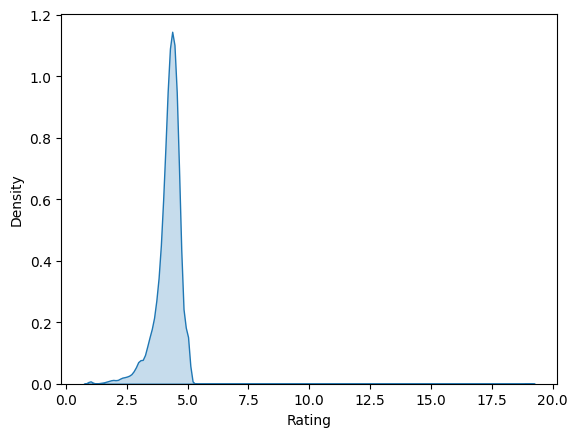

In [392]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(df['Rating'].dropna(), fill=True)
plt.show()

#### No, after looking the distribution, i can say that the data is not normally distributed, from my POV

Which rating range contains most apps?

#### as I can clearly see from the above kde plot, that most apps rating fall from range 3 to 5, so the answer is range(3-5)

How are app sizes distributed?

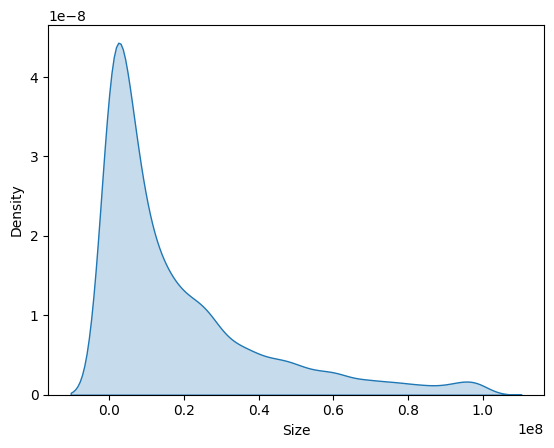

In [393]:
sns.kdeplot(df['Size'].dropna(), fill=True)
plt.show()

#### As we can the above diagram, that the data is not normally distributed, but it looks like the data is left skewed, means most of the app size falls in between 5 to 15 and rest are from 15 to 100

Which content rating category is most common?

In [394]:
content_ratings_cat = df["Content Rating"].value_counts()
print(f"category name: {content_ratings_cat.idxmax()}")
print(f"counts: {content_ratings_cat.max()}")

category name: Everyone
,counts: 8714


What percentage of apps are free?

In [395]:
free_per = len(df[df["Price"] == 0]) / len(df["Price"]) * 100
free_per

92.61138271377179

What percentage are paid?

In [396]:
paid_per = len(df[df["Price"] > 0]) / len(df["Price"]) * 100
paid_per

7.379393044922056

In [397]:
# or
100.0 - free_per

7.388617286228211

What is the maximum price of an app?

In [398]:
max_price = df.loc[df["Price"].idxmax()]
max_price[["App", "Price"]]

App      I'm Rich - Trump Edition
Price                       400.0
Name: 4367, dtype: object

Which category contains the fewest apps?

In [399]:
df = df[df["Category"] != "1.9"]
cat_with_fewer_apps = df.groupby("Category")["App"].count()
print(f"category name: {cat_with_fewer_apps.idxmin()}")
print(f"counts: {cat_with_fewer_apps.min()}")

category name: BEAUTY
,counts: 53


Which category has the highest average rating?

In [400]:
df.groupby("Category")["Rating"].mean().sort_values(ascending=False).head(1)

Category
EVENTS    4.435556
Name: Rating, dtype: float64

Which category has the lowest average rating?

In [401]:
df.groupby("Category")["Rating"].mean().sort_values().head(1)

Category
DATING    3.970769
Name: Rating, dtype: float64

Which category receives the highest total number of reviews?

In [402]:
df.groupby("Category")["Rating"].count().sort_values(ascending=False).head(1)

Category
FAMILY    1747
Name: Rating, dtype: int64

Which category has the highest average installs?

In [403]:
df.groupby("Category")["Installs"].mean().sort_values(ascending=False).head(1)

Category
COMMUNICATION    8.435989e+07
Name: Installs, dtype: float64

Which category has the largest app sizes?

In [404]:
df.groupby("Category")["Size"].max().sort_values(ascending=False).head(1)

Category
HEALTH_AND_FITNESS    100000000
Name: Size, dtype: int64

Which category contains the most paid apps?

In [405]:
df.groupby("Category")["Price"].count().sort_values(ascending=False).head(1)

Category
FAMILY    1972
Name: Price, dtype: int64

Which category contains the highest percentage of free apps?

In [406]:
free_apps_group = df.groupby("Category")["Price"].sum()
free_apps_group[free_apps_group == 0]

Category
BEAUTY            0.0
COMICS            0.0
HOUSE_AND_HOME    0.0
Name: Price, dtype: float64

Are certain categories dominated by a single content rating?

In [407]:
dominated_categories = (
    df.groupby("Category")["Content Rating"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

print("Categories heavily dominated by 'Everyone' content rating:")
print(dominated_categories.sort_values(by="Everyone", ascending=False).head(5))

Categories heavily dominated by 'Everyone' content rating:
,Content Rating      Adults only 18+  Everyone  Everyone 10+  Mature 17+  \
,Category                                                                  
,LIBRARIES_AND_DEMO              0.0  1.000000      0.000000    0.000000   
,TOOLS                           0.0  0.990510      0.000000    0.002372   
,FINANCE                         0.0  0.986339      0.000000    0.000000   
,HOUSE_AND_HOME                  0.0  0.977273      0.000000    0.000000   
,AUTO_AND_VEHICLES               0.0  0.976471      0.011765    0.000000   
,
,Content Rating          Teen   Unrated  
,Category                                
,LIBRARIES_AND_DEMO  0.000000  0.000000  
,TOOLS               0.005931  0.001186  
,FINANCE             0.013661  0.000000  
,HOUSE_AND_HOME      0.022727  0.000000  
,AUTO_AND_VEHICLES   0.011765  0.000000  


What are the top 20 highest-rated apps?

In [408]:
df.groupby("App")["Rating"].max().sort_values(ascending=False).head(20)

App
BI News                                               5.0
EC Calgary                                            5.0
EB Scanner                                            5.0
EB Cash Collections                                   5.0
CJ Gospel Hour                                        5.0
CJ the REALTOR                                        5.0
FK CLASSIC FOR YOU                                    5.0
South Florida AA Meetings                             5.0
NOMISMA.com.cy by FMW                                 5.0
Anatomy & Physiology Vocabulary Exam Review App       5.0
Victoria EC                                           5.0
Dt. Jyothi Srinivas                                   5.0
Bacterial vaginosis Treatment - Sexual disease        5.0
BJ Foods                                              5.0
NEMA ei                                               5.0
NCLEX Multi-topic Nursing Exam Review-Quiz & notes    5.0
FK Dedinje BGD                                        5.0
C B Patel 

Which category contributes most of the 5-star apps?

In [409]:
category_5_star = df.groupby("Category")["Rating"].max().sort_values(ascending=False)
category_5_star[category_5_star == 5.0]

Category
ART_AND_DESIGN         5.0
GAME                   5.0
SPORTS                 5.0
SOCIAL                 5.0
SHOPPING               5.0
PRODUCTIVITY           5.0
PHOTOGRAPHY            5.0
PERSONALIZATION        5.0
PARENTING              5.0
NEWS_AND_MAGAZINES     5.0
MEDICAL                5.0
LIFESTYLE              5.0
LIBRARIES_AND_DEMO     5.0
TRAVEL_AND_LOCAL       5.0
HEALTH_AND_FITNESS     5.0
FOOD_AND_DRINK         5.0
FINANCE                5.0
FAMILY                 5.0
EVENTS                 5.0
DATING                 5.0
COMMUNICATION          5.0
COMICS                 5.0
BUSINESS               5.0
BOOKS_AND_REFERENCE    5.0
TOOLS                  5.0
Name: Rating, dtype: float64

Do apps with more reviews receive higher ratings?

In [410]:
df["Reviews"].corr(df["Rating"])

np.float64(0.0681414670009902)

#### i can't see any strong relation between the apps who getting more reviews receive higher ratings

Do highly installed apps have better ratings?

In [411]:
df.groupby("Installs")["Rating"].mean().sort_index(ascending=True)

Installs
0.000000e+00         NaN
1.000000e+00    5.000000
5.000000e+00    4.611111
1.000000e+01    4.624638
5.000000e+01    4.419643
1.000000e+02    4.363430
5.000000e+02    4.176617
1.000000e+03    4.066760
5.000000e+03    4.024537
1.000000e+04    4.039703
5.000000e+04    4.051178
1.000000e+05    4.110261
5.000000e+05    4.168216
1.000000e+06    4.220862
5.000000e+06    4.243218
1.000000e+07    4.313419
5.000000e+07    4.351211
1.000000e+08    4.411491
5.000000e+08    4.350000
1.000000e+09    4.258621
Name: Rating, dtype: float64

Which category has the greatest variation in ratings?

In [412]:
df.groupby("Category")["Rating"].std().sort_values(ascending=False).head(5)

Category
LIFESTYLE    0.693907
MEDICAL      0.663581
FINANCE      0.642108
DATING       0.630510
BUSINESS     0.624422
Name: Rating, dtype: float64

Are ratings different between free and paid apps?

In [413]:
free_app_rating = df[df["Price"] == 0]
paid_app_rating = df[df["Price"] > 0]

print(f"Avg rating of free apps: {free_app_rating["Rating"].mean()}")
print(f"Avg rating is paid apps: {paid_app_rating["Rating"].mean()}")

Avg rating of free apps: 4.186202546163551
,Avg rating is paid apps: 4.26661514683153


In [414]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [415]:
df.info()

<class 'pandas.DataFrame'>
,Index: 10840 entries, 0 to 10840
,Data columns (total 13 columns):
, #   Column          Non-Null Count  Dtype  
,---  ------          --------------  -----  
, 0   App             10840 non-null  str    
, 1   Category        10840 non-null  str    
, 2   Rating          9366 non-null   float64
, 3   Reviews         10840 non-null  int64  
, 4   Size            10840 non-null  int64  
, 5   Installs        10840 non-null  float64
, 6   Type            10839 non-null  str    
, 7   Price           10840 non-null  float64
, 8   Content Rating  10840 non-null  str    
, 9   Genres          10840 non-null  str    
, 10  Last Updated    10840 non-null  str    
, 11  Current Ver     10832 non-null  str    
, 12  Android Ver     10838 non-null  str    
,dtypes: float64(3), int64(2), str(8)
,memory usage: 2.1 MB


In [416]:
df["Installs"] = df["Installs"].fillna(0).astype(int)
df["Rating"] = df["Rating"].fillna(0).astype(int)
df.info()

<class 'pandas.DataFrame'>
,Index: 10840 entries, 0 to 10840
,Data columns (total 13 columns):
, #   Column          Non-Null Count  Dtype  
,---  ------          --------------  -----  
, 0   App             10840 non-null  str    
, 1   Category        10840 non-null  str    
, 2   Rating          10840 non-null  int64  
, 3   Reviews         10840 non-null  int64  
, 4   Size            10840 non-null  int64  
, 5   Installs        10840 non-null  int64  
, 6   Type            10839 non-null  str    
, 7   Price           10840 non-null  float64
, 8   Content Rating  10840 non-null  str    
, 9   Genres          10840 non-null  str    
, 10  Last Updated    10840 non-null  str    
, 11  Current Ver     10832 non-null  str    
, 12  Android Ver     10838 non-null  str    
,dtypes: float64(1), int64(4), str(8)
,memory usage: 2.1 MB


In [417]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4,159,19000000,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3,967,14000000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4,87510,8700000,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4,215644,25000000,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4,967,2800000,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


Which apps have the highest installs?

In [418]:
df["Installs"].unique()

array([     10000,     500000,    5000000,   50000000,     100000,
            50000,    1000000,   10000000,       5000,  100000000,
       1000000000,       1000,  500000000,         50,        100,
              500,         10,          1,          5,          0])

In [419]:
df.groupby("App")["Installs"].max().head(1)

App
"i DT" Fútbol. Todos Somos Técnicos.    500
Name: Installs, dtype: int64

Do larger apps tend to have higher ratings?

In [420]:
df["Size"].corr(df["Rating"])

np.float64(0.09546325208984638)

<Axes: xlabel='Size', ylabel='Rating'>

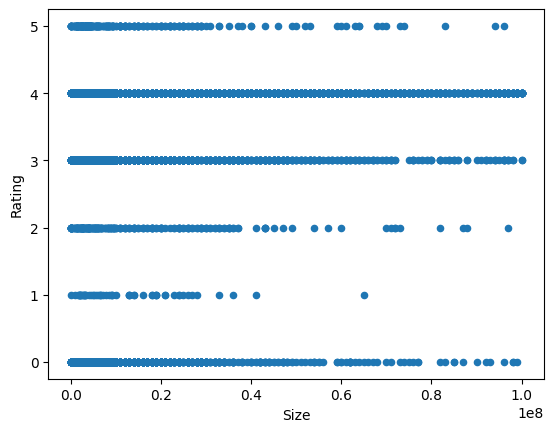

In [421]:
df.plot("Size", "Rating", kind = "scatter")

Are older apps rated differently than recently updated apps?

In [422]:
from datetime import datetime
today = datetime.today()
print(today)
df["difference_between_last_update_till_now"] = (today - pd.to_datetime(df["Last Updated"])).dt.days

2026-06-24 17:51:59.485861


In [423]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,difference_between_last_update_till_now
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4,159,19000000,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,3090
1,Coloring book moana,ART_AND_DESIGN,3,967,14000000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,3082
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4,87510,8700000,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,2884
3,Sketch - Draw & Paint,ART_AND_DESIGN,4,215644,25000000,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,2938
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4,967,2800000,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2926


In [424]:
df.sort_values(by="difference_between_last_update_till_now")

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,difference_between_last_update_till_now
10408,Shoot Hunter-Gun Killer,GAME,4,320334,27000000,50000000,Free,0.00,Teen,Action,"August 8, 2018",1.1.2,4.1 and up,2877
10209,Video Downloader For FB: Save FB Videos 2018,TOOLS,4,434,3600000,50000,Free,0.00,Everyone,Tools,"August 8, 2018",1.1.9,4.0.3 and up,2877
10712,Lalafo Pulsuz Elanlar,SHOPPING,4,61392,0,1000000,Free,0.00,Everyone,Shopping,"August 8, 2018",Varies with device,Varies with device,2877
10718,BankNordik,FINANCE,3,28,15000000,5000,Free,0.00,Everyone,Finance,"August 8, 2018",7.3.2,5.0 and up,2877
10760,Fast Tract Diet,HEALTH_AND_FITNESS,4,35,2400000,1000,Paid,7.99,Everyone,Health & Fitness,"August 8, 2018",1.9.3,4.2 and up,2877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8084,Freecell CY,GAME,4,387,1100000,50000,Free,0.00,Everyone,Card,"April 16, 2011",1.3.3,1.6 and up,5548
8418,DEER HUNTER CHALLENGE,GAME,3,38767,4100000,5000000,Free,0.00,Everyone 10+,Action,"April 11, 2011",1.4.3,2.0 and up,5553
10282,FD Shift Calendar Widget,TOOLS,4,981,73000,100000,Free,0.00,Everyone,Tools,"March 16, 2011",1.2.4,1.6 and up,5579
7430,CJ Poker Odds Calculator,GAME,4,207,116000,50000,Free,0.00,Everyone,Card,"January 30, 2011",1.2,1.6 and up,5624


In [425]:
# let's split the data into two parts, one is new apps and other is old apps
midpoint = len(df) // 2
new_apps = df.iloc[:midpoint, :]
old_apps = df.iloc[midpoint:, :]

In [426]:
new_apps.groupby("App")["Rating"].sum().mean()

np.float64(4.398519847499439)

In [427]:
old_apps.groupby("App")["Rating"].sum().mean()

np.float64(2.912177121771218)

Which category has the most consistent ratings?

In [428]:
df.groupby("Category")["Rating"].std().sort_values(ascending=True).head(5)

Category
EDUCATION         0.371214
ENTERTAINMENT     0.448105
GAME              0.861798
COMICS            0.869281
ART_AND_DESIGN    0.892813
Name: Rating, dtype: float64

Which category contributes the highest total installs?

In [429]:
df.groupby("Category")["Installs"].max().sort_values(ascending=False).head(1)

Category
FAMILY    1000000000
Name: Installs, dtype: int64

What is the relationship between reviews and ratings?

In [430]:
df["Reviews"].corr(df["Rating"])

np.float64(0.07881894071045834)

Do paid apps receive fewer installs than free apps?

In [431]:
paid_apps = df[df["Price"] > 0]
free_apps = df[df["Price"] == 0]

paid_apps_installs = paid_apps.groupby("App")["Installs"].sum().count()
free_apps_installs = free_apps.groupby("App")["Installs"].sum().count()

print(paid_apps_installs)
print(free_apps_installs)

756
,8905


What percentage of apps have fewer than 10,000 installs?

In [432]:
(df["Installs"] < 10000).mean() * 100

np.float64(29.40959409594096)

Are highly-rated apps downloaded more frequently?

In [433]:
df['Rating'].corr(df['Installs'])

np.float64(0.08834385215595879)

Which content-rating group has the highest installs?

In [434]:
df.groupby("Content Rating")["Installs"].sum().sort_values(ascending=False).head(1)

Content Rating
Everyone    114156659621
Name: Installs, dtype: int64

Which category contains the greatest number of apps with over 1 million installs?

In [435]:
df[df['Installs'] > 1000000].groupby('Category')['App'].count().sort_values(ascending=False).head(1)

Category
GAME    571
Name: App, dtype: int64

Are installs concentrated among a few apps?

In [17]:

install_counts = df['Installs'].value_counts(normalize=True).sort_index()
print(install_counts.head(10))



Installs
0            0.001384
1            0.006180
10           0.035606
100          0.066322
1000         0.083664
10000        0.097224
100000       0.107831
1000000      0.145651
10000000     0.115488
100000000    0.037727
Name: proportion, dtype: float64


What is the average price of paid apps?

In [437]:
paid_apps = df[df['Price'] > 0]
paid_apps['Price'].mean()

np.float64(13.920837500000003)

Which category has the most expensive apps?

In [438]:
df.groupby('Category')['Price'].max().sort_values(ascending=False).head(1)

Category
LIFESTYLE    400.0
Name: Price, dtype: float64

What is the distribution of installs?

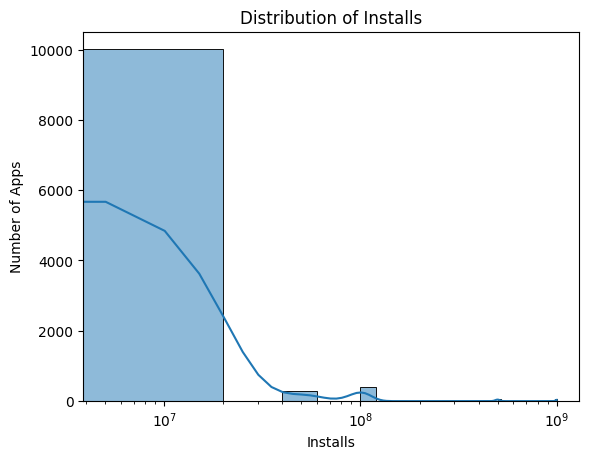

In [439]:
sns.histplot(df['Installs'], bins=50, kde=True)
plt.title('Distribution of Installs')
plt.xlabel('Installs')
plt.ylabel('Number of Apps')
plt.xscale('log')
plt.show()

Which genre contains the largest number of apps?

In [440]:
df['Genres'].value_counts().sort_values(ascending=False).head(1)

Genres
Tools    842
Name: count, dtype: int64

No specific answer to this text cell, so skipping with a markdown cell.

In [441]:
df['Price'].corr(df['Rating'])

np.float64(-0.01835328306196882)

No specific answer to this text cell, so skipping with a markdown cell.

Which app is the most expensive?

In [442]:
max_price_app = df.loc[df['Price'].idxmax()]
max_price_app[['App', 'Price']]

App      I'm Rich - Trump Edition
Price                       400.0
Name: 4367, dtype: object

Which category generates the highest total revenue potential?

In [443]:
df['Revenue_Potential'] = df['Price'] * df['Installs']
df.groupby('Category')['Revenue_Potential'].sum().sort_values(ascending=False).head(1)

Category
FAMILY    1.860526e+08
Name: Revenue_Potential, dtype: float64

Does price affect installs?

In [444]:
df['Price'].corr(df['Installs'])

np.float64(-0.011689470477901578)

Do paid apps receive more reviews than free apps?

In [445]:
print(f"Average reviews for free apps: {free_apps['Reviews'].mean()}")
print(f"Average reviews for paid apps: {paid_apps['Reviews'].mean()}")

Average reviews for free apps: 478613.4206175299
,Average reviews for paid apps: 11673.3125


What percentage of apps cost more than $10? and Figure out some other pricing ranges?

In [446]:
apps_over_10 = df[df['Price'] > 10]
percentage_over_10 = (len(apps_over_10) / len(df)) * 100
print(f"Percentage of apps costing more than $10: {percentage_over_10:.2f}%")


bins = [0, 1, 5, 10, 50, df['Price'].max()]
labels = ['Free-1', '1-5', '5-10', '10-50', '50+']
df['Price_Range'] = pd.cut(df['Price'], bins=bins, labels=labels, right=False)
price_range_percentages = df['Price_Range'].value_counts(normalize=True) * 100
print("\nPercentage of apps in different pricing ranges:")
print(price_range_percentages)

Percentage of apps costing more than $10: 0.82%
,
,Percentage of apps in different pricing ranges:
,Price_Range
,Free-1    93.993911
,1-5        4.299290
,5-10       0.867239
,10-50      0.627364
,50+        0.212197
,Name: proportion, dtype: float64


Is there a relationship between app size and price?

In [447]:
df['Size'].corr(df['Price'])

np.float64(-0.013457255005443222)

In which year were the most apps updated?

In [448]:
df['Last_Updated_Year'] = pd.to_datetime(df['Last Updated']).dt.year
df['Last_Updated_Year'].value_counts().sort_values(ascending=False).head(1)

Last_Updated_Year
2018    7349
Name: count, dtype: int64

No specific answer to this text cell, so skipping with a markdown cell.

Have app ratings improved over the years?

Last_Updated_Year
,2010    4.000000
,2011    3.533333
,2012    2.807692
,2013    3.172727
,2014    3.311005
,2015    3.080610
,2016    2.947761
,2017    2.966792
,2018    3.388624
,Name: Rating, dtype: float64


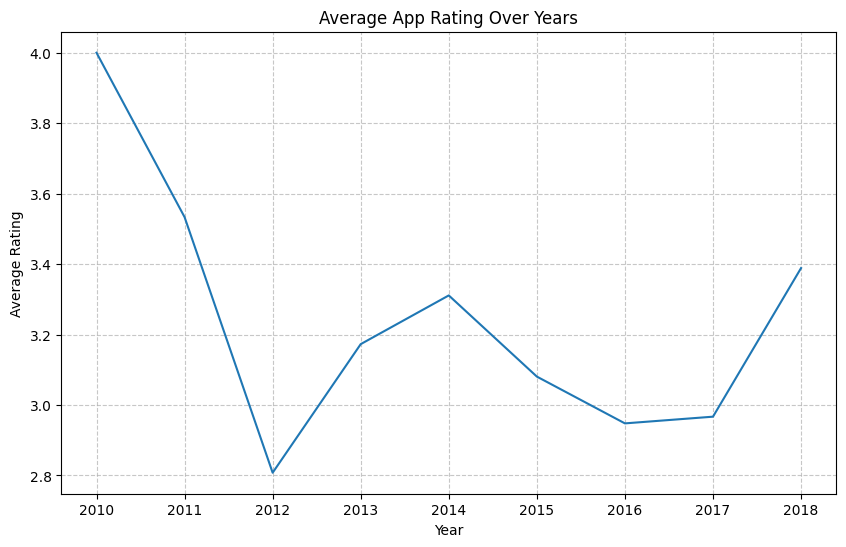

In [449]:
df['Last_Updated_Year'] = pd.to_datetime(df['Last Updated']).dt.year
mean_rating_by_year = df.groupby('Last_Updated_Year')['Rating'].mean()
print(mean_rating_by_year)

plt.figure(figsize=(10, 6))
sns.lineplot(x=mean_rating_by_year.index, y=mean_rating_by_year.values)
plt.title('Average App Rating Over Years')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

What proportion of apps have not been updated in the last two years?

In [450]:
two_years_ago = (pd.to_datetime(today) - pd.DateOffset(years=2)).day
outdated_apps = df[df['difference_between_last_update_till_now'] > 730] # 2 years * 365 days
proportion_outdated = (len(outdated_apps) / len(df)) * 100
print(f"Proportion of apps not updated in the last two years: {proportion_outdated:.2f}%")

Proportion of apps not updated in the last two years: 100.00%


Which content rating has the highest average rating?

In [451]:
df.groupby('Content Rating')['Rating'].mean().sort_values(ascending=False).head(1)

Content Rating
Everyone 10+    3.693237
Name: Rating, dtype: float64

Which categories have many outdated apps?

In [452]:
outdated_apps = df[df['difference_between_last_update_till_now'] > 730]
outdated_apps.groupby('Category')['App'].count().sort_values(ascending=False).head(5)

Category
FAMILY      1972
GAME        1144
TOOLS        843
MEDICAL      463
BUSINESS     460
Name: App, dtype: int64

Which content rating gets the most reviews?

In [453]:
df.groupby('Content Rating')['Reviews'].sum().sort_values(ascending=False).head(1)

Content Rating
Everyone    2801847376
Name: Reviews, dtype: int64

Are Mature 17+ apps generally more expensive?

In [454]:
mature_apps = df[df['Content Rating'] == 'Mature 17+']
other_apps = df[df['Content Rating'] != 'Mature 17+']

print(f"Average price of Mature 17+ apps: {mature_apps['Price'].mean():.2f}")
print(f"Average price of other apps: {other_apps['Price'].mean():.2f}")

Average price of Mature 17+ apps: 0.24
,Average price of other apps: 1.07


Which genre contains the most expensive apps?

In [455]:
df.groupby('Genres')['Price'].max().sort_values(ascending=False).head(1)

Genres
Lifestyle    400.0
Name: Price, dtype: float64

# Relationship Analysis
    Relationship between Reviews and Installs?



    Relationship between Price and Installs?



    Relationship between Size and Rating?



    Relationship between Reviews and Rating?



    Relationship between Size and Installs?



    Relationship between Price and Reviews?



    Relationship between App Size and Revenue Potential?

In [456]:
print(f"Correlation between Reviews and Installs: {df['Reviews'].corr(df['Installs']):.2f}")
print(f"Correlation between Price and Installs: {df['Price'].corr(df['Installs']):.2f}")
print(f"Correlation between Size and Rating: {df['Size'].corr(df['Rating']):.2f}")
print(f"Correlation between Reviews and Rating: {df['Reviews'].corr(df['Rating']):.2f}")
print(f"Correlation between Size and Installs: {df['Size'].corr(df['Installs']):.2f}")
print(f"Correlation between Price and Reviews: {df['Price'].corr(df['Reviews']):.2f}")

df['Revenue_Potential'] = df['Price'] * df['Installs']
print(f"Correlation between App Size and Revenue Potential: {df['Size'].corr(df['Revenue_Potential']):.2f}")

Correlation between Reviews and Installs: 0.64
,Correlation between Price and Installs: -0.01
,Correlation between Size and Rating: 0.10
,Correlation between Reviews and Rating: 0.08
,Correlation between Size and Installs: -0.00
,Correlation between Price and Reviews: -0.01
,Correlation between App Size and Revenue Potential: -0.01


Do free and paid apps have significantly different ratings?

In [457]:
print(f"Average rating of free apps: {free_app_rating['Rating'].mean():.2f}")
print(f"Average rating of paid apps: {paid_app_rating['Rating'].mean():.2f}")

Average rating of free apps: 4.19
,Average rating of paid apps: 4.27


Are Type and Content Rating independent?

In [458]:
contingency_table = pd.crosstab(df['Type'], df['Content Rating'])
print("Contingency Table (Type vs. Content Rating):")
print(contingency_table)

from scipy.stats import chi2_contingency
chi2, p_value, _, _ = chi2_contingency(contingency_table)
print(f"\nChi-squared statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("There is a significant relationship between Type and Content Rating (reject null hypothesis of independence).")
else:
    print("There is no significant relationship between Type and Content Rating (fail to reject null hypothesis of independence).")

Contingency Table (Type vs. Content Rating):
,Content Rating  Adults only 18+  Everyone  Everyone 10+  Mature 17+  Teen  \
,Type                                                                        
,Free                          3      8019           380         479  1156   
,Paid                          0       695            33          20    52   
,
,Content Rating  Unrated  
,Type                     
,Free                  2  
,Paid                  0  
,
,Chi-squared statistic: 30.16
,P-value: 0.000
,There is a significant relationship between Type and Content Rating (reject null hypothesis of independence).


Create a Revenue Potential feature
use Revenue = Price × Installs

In [459]:
df['Revenue_Potential'] = df['Price'] * df['Installs']
df[['App', 'Price', 'Installs', 'Revenue_Potential']].head()

,App,Price,Installs,Revenue_Potential
0,Photo Editor & Candy Camera & Grid & ScrapBook,0.0,10000,0.0
1,Coloring book moana,0.0,500000,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",0.0,5000000,0.0
3,Sketch - Draw & Paint,0.0,50000000,0.0
4,Pixel Draw - Number Art Coloring Book,0.0,100000,0.0


Which category has the highest revenue potential?

In [460]:
df.groupby('Category')['Revenue_Potential'].sum().sort_values(ascending=False).head(1)

Category
FAMILY    1.860526e+08
Name: Revenue_Potential, dtype: float64

Create a Review-to-Install Ratio:

Review_Ratio = Reviews / Installs



In [461]:
df['Review_Ratio'] = df['Reviews'] / df['Installs']
df['Review_Ratio'] = df['Review_Ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)
df[['App', 'Reviews', 'Installs', 'Review_Ratio']].head()

,App,Reviews,Installs,Review_Ratio
0,Photo Editor & Candy Camera & Grid & ScrapBook,159,10000,0.015900
1,Coloring book moana,967,500000,0.001934
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",87510,5000000,0.017502
3,Sketch - Draw & Paint,215644,50000000,0.004313
4,Pixel Draw - Number Art Coloring Book,967,100000,0.009670


Which apps have the most engaged users?

In [462]:
df.sort_values(by='Review_Ratio', ascending=False)[['App', 'Review_Ratio', 'Reviews', 'Installs']].head(10)

,App,Review_Ratio,Reviews,Installs
2454,KBA-EZ Health Guide,4.0,4,1
4550,RMEduS - 음성인식을 활용한 R 프로그래밍 실습 시스템,4.0,4,1
5917,Ra Ga Ba,2.0,2,1
5812,AX Watch for WatchMaker,2.0,2,1
10697,Mu.F.O.,2.0,2,1
8591,DN Blog,2.0,20,10
9096,DZ Puzzle,1.4,14,10
6700,Brick Breaker BR,1.4,7,5
6508,Sam.BN Pro,1.1,11,10
7402,Trovami se ci riesci,1.1,11,10


Create an App Age feature:

App_Age = Current Year − Last Updated Year

In [463]:
current_year = pd.to_datetime(today).year
df['App_Age'] = current_year - pd.to_datetime(df['Last Updated']).dt.year
df[['App', 'Last Updated', 'App_Age']].head()

,App,Last Updated,App_Age
0,Photo Editor & Candy Camera & Grid & ScrapBook,"January 7, 2018",8
1,Coloring book moana,"January 15, 2018",8
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...","August 1, 2018",8
3,Sketch - Draw & Paint,"June 8, 2018",8
4,Pixel Draw - Number Art Coloring Book,"June 20, 2018",8


Do newer apps perform better?

In [464]:
print(f"Correlation between App Age and Rating: {df['App_Age'].corr(df['Rating']):.2f}")
print(f"Correlation between App Age and Installs: {df['App_Age'].corr(df['Installs']):.2f}")

Correlation between App Age and Rating: -0.08
,Correlation between App Age and Installs: -0.09


Create a Success Index:

Success_Index =
0.2 × Normalized Rating +
0.4 × Normalized Installs +
0.3 × Normalized Reviews



In [465]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Normalized_Rating'] = scaler.fit_transform(df[['Rating']])
df['Normalized_Installs'] = scaler.fit_transform(df[['Installs']])
df['Normalized_Reviews'] = scaler.fit_transform(df[['Reviews']])

df['Success_Index'] = (0.2 * df['Normalized_Rating']) + \
                      (0.4 * df['Normalized_Installs']) + \
                      (0.3 * df['Normalized_Reviews'])
df[['App', 'Rating', 'Installs', 'Reviews', 'Success_Index']].head()

,App,Rating,Installs,Reviews,Success_Index
0,Photo Editor & Candy Camera & Grid & ScrapBook,4,10000,159,0.160005
1,Coloring book moana,3,500000,967,0.120204
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4,5000000,87510,0.162336
3,Sketch - Draw & Paint,4,50000000,215644,0.180828
4,Pixel Draw - Number Art Coloring Book,4,100000,967,0.160044


Which apps are the most successful?

In [466]:
df.sort_values(by='Success_Index', ascending=False)[['App', 'Success_Index', 'Rating', 'Installs', 'Reviews']].head(10)

,App,Success_Index,Rating,Installs,Reviews
2544,Facebook,0.860000,4,1000000000,78158306
3943,Facebook,0.859884,4,1000000000,78128208
336,WhatsApp Messenger,0.825305,4,1000000000,69119316
381,WhatsApp Messenger,0.825305,4,1000000000,69119316
3904,WhatsApp Messenger,0.825268,4,1000000000,69109672
2604,Instagram,0.815548,4,1000000000,66577446
2611,Instagram,0.815548,4,1000000000,66577313
2545,Instagram,0.815548,4,1000000000,66577313
3909,Instagram,0.815289,4,1000000000,66509917
382,Messenger – Text and Video Chat for Free,0.777430,4,1000000000,56646578


Do free apps with in-app purchases (inferred from low price + high reviews) outperform truly free apps in terms of rating and installs?

In [467]:

in_app_purchase_threshold = 1.0

truly_free_apps = df[df['Price'] == 0]
potential_in_app_apps = df[(df['Price'] > 0) & (df['Price'] <= in_app_purchase_threshold)]

print(f"Average Rating - Truly Free Apps: {truly_free_apps['Rating'].mean():.2f}")
print(f"Average Installs - Truly Free Apps: {truly_free_apps['Installs'].mean():.2e}")

print(f"\nAverage Rating - Potential In-App Purchase Apps: {potential_in_app_apps['Rating'].mean():.2f}")
print(f"Average Installs - Potential In-App Purchase Apps: {potential_in_app_apps['Installs'].mean():.2e}")

high_reviews_threshold = df['Reviews'].median()
high_review_low_price_apps = df[(df['Price'] > 0) & (df['Price'] <= in_app_purchase_threshold) & (df['Reviews'] > high_reviews_threshold)]

print(f"\nAverage Rating - High Review & Low Price Paid Apps: {high_review_low_price_apps['Rating'].mean():.2f}")
print(f"Average Installs - High Review & Low Price Paid Apps: {high_review_low_price_apps['Installs'].mean():.2e}")

Average Rating - Truly Free Apps: 3.28
,Average Installs - Truly Free Apps: 1.67e+07
,
,Average Rating - Potential In-App Purchase Apps: 2.83
,Average Installs - Potential In-App Purchase Apps: 1.35e+05
,
,Average Rating - High Review & Low Price Paid Apps: 4.00
,Average Installs - High Review & Low Price Paid Apps: 1.12e+06


Which categories show the steepest "update fatigue" — apps that were last updated 2+ years ago but still have high install counts?

In [468]:
outdated_and_high_installs = df[(df['difference_between_last_update_till_now'] > 730) & (df['Installs'] > df['Installs'].median())]
outdated_and_high_installs.groupby('Category')['App'].count().sort_values(ascending=False).head(5)

Category
GAME             799
FAMILY           760
TOOLS            315
PHOTOGRAPHY      239
COMMUNICATION    221
Name: App, dtype: int64

Do apps that launched earlier (older Last Updated year) show declining ratings over time

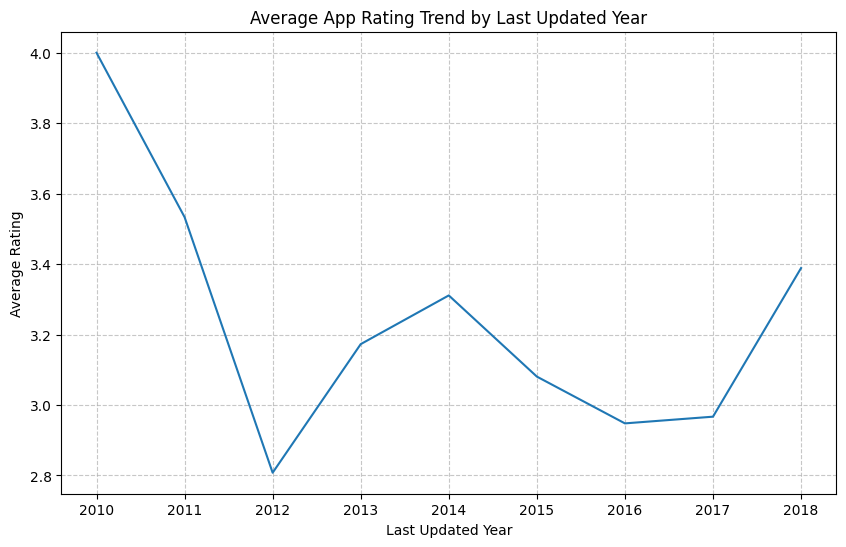

Correlation between App Age and Rating: -0.08


In [469]:
df['Last_Updated_Year'] = pd.to_datetime(df['Last Updated']).dt.year
mean_rating_by_year = df.groupby('Last_Updated_Year')['Rating'].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=mean_rating_by_year.index, y=mean_rating_by_year.values)
plt.title('Average App Rating Trend by Last Updated Year')
plt.xlabel('Last Updated Year')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Correlation between App Age and Rating: {df['App_Age'].corr(df['Rating']):.2f}")